# Reinforcement Learning

Reinforcement Learning (RL) is a branch of machine learning in which an
**agent learns how to make decisions by interacting with an environment**.

Unlike supervised learning, the agent is not given the correct action for
each state. Instead, it receives rewards or penalties and learns a strategy
that maximizes its long-term cumulative reward.

This notebook covers:

- Reinforcement Learning fundamentals
- Markov Decision Processes
- Policies and value functions
- Bellman equations
- Exploration vs exploitation
- Multi-armed bandits
- Monte Carlo learning
- Temporal-Difference learning
- Q-Learning
- SARSA
- GridWorld
- Policy and value visualization
- Deep Q-Networks (DQN)
- Experience replay
- Target networks
- RL evaluation and limitations

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict

np.random.seed(42)

## 1. What is Reinforcement Learning?

Reinforcement Learning is a learning framework based on **interaction**.

The basic loop is:

$$
\text{Agent}
\rightarrow
\text{Action}
\rightarrow
\text{Environment}
\rightarrow
\text{Reward + Next State}
$$

The agent repeatedly interacts with the environment and gradually learns
which actions are useful.

### Examples

Reinforcement Learning can be applied to:

- Game playing
- Robotics
- Autonomous systems
- Recommendation systems
- Resource allocation
- Traffic control
- Portfolio management
- Industrial control

The key difference from supervised learning is that the agent usually does
not receive an explicit label such as:

$$
\text{state} \rightarrow \text{correct action}
$$

Instead, it receives feedback through rewards.

## 2. Agent–Environment Interaction

At time step $t$, the agent observes a state:

$$
S_t
$$

The agent selects an action:

$$
A_t
$$

The environment then produces a reward:

$$
R_{t+1}
$$

and transitions to a new state:

$$
S_{t+1}
$$

The complete interaction is:

$$
S_t
\rightarrow
A_t
\rightarrow
R_{t+1}, S_{t+1}
$$

The objective is not necessarily to maximize the immediate reward.

Instead, the agent tries to maximize **long-term cumulative reward**.

## 3. Core Reinforcement Learning Terminology

| Concept | Meaning |
|---|---|
| Agent | Learner or decision maker |
| Environment | World in which the agent operates |
| State | Current situation |
| Action | Decision made by the agent |
| Reward | Feedback from the environment |
| Policy | Strategy used to select actions |
| Value Function | Expected long-term return from a state |
| Q-Function | Expected long-term return from a state-action pair |
| Episode | One complete interaction sequence |
| Return | Cumulative discounted reward |
| Discount Factor | Controls the importance of future rewards |

## 4. Markov Decision Process

A large class of reinforcement learning problems can be represented as a
**Markov Decision Process (MDP)**.

An MDP is commonly represented as:

$$
\mathcal{M} = (\mathcal{S}, \mathcal{A}, P, R, \gamma)
$$

where:

- $\mathcal{S}$ = set of states
- $\mathcal{A}$ = set of actions
- $P$ = transition probability
- $R$ = reward function
- $\gamma$ = discount factor

### Markov Property

The Markov property states that the future depends on the current state
rather than the complete history.

$$
P(S_{t+1} \mid S_t, A_t)
$$

contains the relevant information needed to describe the transition.

This assumption is extremely important in classical reinforcement learning.

## 5. Return

The **return** is the cumulative reward obtained from a particular time
step onward.

The discounted return is:

$$
G_t =
R_{t+1}
+
\gamma R_{t+2}
+
\gamma^2 R_{t+3}
+
\cdots
$$

where:

$$
0 \leq \gamma \leq 1
$$

is the discount factor.

### Interpretation

If $\gamma$ is close to $0$, the agent focuses more on immediate rewards.

If $\gamma$ is close to $1$, future rewards become more important.

For example:

$$
G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3}
$$


In [2]:
def discounted_return(rewards, gamma=0.9):
    total = 0.0

    for t, reward in enumerate(rewards):
        total += (gamma ** t) * reward

    return total


rewards = [1, 2, 3, 4]

print("Rewards:", rewards)
print("Discounted return:", discounted_return(rewards, gamma=0.9))

Rewards: [1, 2, 3, 4]
Discounted return: 8.146


## 6. Policy

A **policy** describes how an agent chooses actions.

A deterministic policy can be written as:

$$
A_t = \pi(S_t)
$$

A stochastic policy represents the probability of selecting an action:

$$
\pi(a \mid s)
=
P(A_t = a \mid S_t = s)
$$

A good policy should produce high long-term return.

## 7. State-Value Function

The value function measures the expected return from a state while following
a particular policy.

It is defined as:

$$
V^\pi(s)
=
\mathbb{E}_\pi[G_t \mid S_t=s]
$$

The value function answers:

> "How good is it to be in this state?"

---

## Action-Value Function

The action-value function, or Q-function, measures the expected return from
taking action $a$ in state $s$ and then following policy $\pi$.

$$
Q^\pi(s,a)
=
\mathbb{E}_\pi[G_t \mid S_t=s,A_t=a]
$$

It answers:

> "How good is it to take this action in this state?"

## 8. Bellman Equation

The Bellman equation expresses the value of a state in terms of its immediate
reward and the value of future states.

For a policy $\pi$:

$$
V^\pi(s)
=
\mathbb{E}_\pi
\left[
R_{t+1}
+
\gamma V^\pi(S_{t+1})
\mid S_t=s
\right]
$$

The key idea is:

$$
\text{Current Value}
=
\text{Immediate Reward}
+
\text{Discounted Future Value}
$$

This recursive structure is fundamental to many reinforcement learning
algorithms.

## 9. Exploration vs Exploitation

An RL agent faces an important trade-off.

### Exploitation

Choose the action currently believed to be best.

### Exploration

Try actions that may provide better information.

An agent that only exploits may never discover a better strategy.

An agent that only explores may never take advantage of what it has learned.

A common strategy is **epsilon-greedy action selection**.

With probability $\epsilon$:

$$
\text{choose a random action}
$$

With probability $1-\epsilon$:

$$
\text{choose the action with highest estimated value}
$$

In [3]:
def epsilon_greedy(Q, state, epsilon, n_actions):
    if np.random.random() < epsilon:
        return np.random.randint(n_actions)

    return np.argmax(Q[state])

## 10. Multi-Armed Bandits

A multi-armed bandit consists of several actions with unknown reward
distributions.

The agent must determine which actions produce high rewards.

Unlike a full MDP:

- there may be no meaningful state transitions
- actions produce rewards directly
- the main challenge is exploration vs exploitation

This provides a simple introduction to RL decision making.

In [4]:
class MultiArmedBandit:
    def __init__(self, true_means):
        self.true_means = np.array(true_means)

    def step(self, action):
        return np.random.normal(self.true_means[action], 1.0)


bandit = MultiArmedBandit([0.2, 0.5, 1.0, 0.7, 0.3])

print("True action means:", bandit.true_means)

True action means: [0.2 0.5 1.  0.7 0.3]


## 11. Monte Carlo Methods

Monte Carlo reinforcement learning estimates values from complete episodes.

After an episode finishes, we calculate the observed return:

$$
G_t =
R_{t+1}
+
\gamma R_{t+2}
+
\gamma^2 R_{t+3}
+\cdots
$$

The estimated value can then be updated using observed returns.

Monte Carlo methods therefore:

- require complete episodes
- learn from actual returns
- do not require a model of the environment

A major limitation is that we must generally wait until the episode ends.

## 12. Temporal-Difference Learning

Temporal-Difference (TD) learning combines ideas from Monte Carlo learning
and dynamic programming.

Instead of waiting until the episode ends, TD learning updates estimates
using the next state.

The basic TD target is:

$$
R_{t+1}
+
\gamma V(S_{t+1})
$$

The TD error is:

$$
\delta_t
=
R_{t+1}
+
\gamma V(S_{t+1})
-
V(S_t)
$$

The value update is:

$$
V(S_t)
\leftarrow
V(S_t)
+
\alpha \delta_t
$$

where $\alpha$ is the learning rate.

## 13. Q-Learning

Q-Learning is an **off-policy temporal-difference learning algorithm**.

It learns the optimal action-value function:

$$
Q^*(s,a)
$$

The Q-Learning update is:

$$
Q(s,a)
\leftarrow
Q(s,a)
+
\alpha
\left[
r
+
\gamma
\max_{a'}
Q(s',a')
-
Q(s,a)
\right]
$$

where:

- $\alpha$ = learning rate
- $\gamma$ = discount factor
- $r$ = immediate reward
- $s'$ = next state

The term

$$
r + \gamma \max_{a'} Q(s',a')
$$

is the TD target.

The difference between the target and current estimate is the TD error.

## Build GridWorld

In [5]:
class GridWorld:
    def __init__(self, size=5):
        self.size = size
        self.start = (0, 0)
        self.goal = (size - 1, size - 1)

        self.actions = {
            0: (-1, 0),  # up
            1: (1, 0),   # down
            2: (0, -1),  # left
            3: (0, 1)    # right
        }

        self.n_actions = len(self.actions)
        self.reset()

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        row, col = self.state
        dr, dc = self.actions[action]

        new_row = np.clip(row + dr, 0, self.size - 1)
        new_col = np.clip(col + dc, 0, self.size - 1)

        self.state = (new_row, new_col)

        done = self.state == self.goal

        reward = 10 if done else -1

        return self.state, reward, done

## Visualize GridWorld

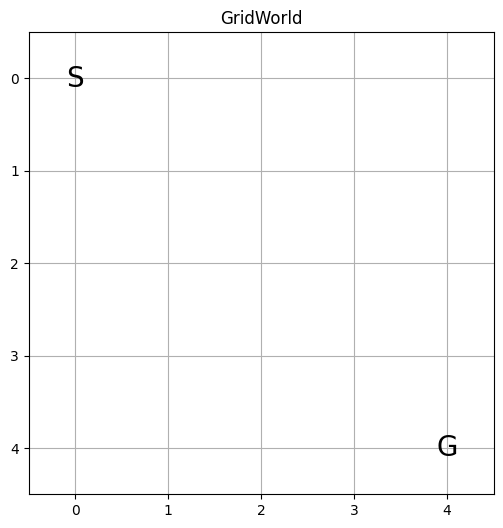

In [6]:
env = GridWorld(size=5)

fig, ax = plt.subplots(figsize=(6, 6))

ax.set_xlim(-0.5, env.size - 0.5)
ax.set_ylim(env.size - 0.5, -0.5)

ax.set_xticks(range(env.size))
ax.set_yticks(range(env.size))
ax.grid(True)

ax.text(
    env.start[1],
    env.start[0],
    "S",
    ha="center",
    va="center",
    fontsize=20
)

ax.text(
    env.goal[1],
    env.goal[0],
    "G",
    ha="center",
    va="center",
    fontsize=20
)

plt.title("GridWorld")
plt.show()

## Q-Learning implementation

In [7]:
def q_learning(
    env,
    episodes=1000,
    alpha=0.1,
    gamma=0.95,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.05,
    max_steps=200
):
    Q = defaultdict(lambda: np.zeros(env.n_actions))

    episode_rewards = []
    episode_steps = []

    for episode in range(episodes):
        state = env.reset()

        total_reward = 0
        steps = 0

        for step in range(max_steps):
            action = epsilon_greedy(
                Q,
                state,
                epsilon,
                env.n_actions
            )

            next_state, reward, done = env.step(action)

            best_next_value = np.max(Q[next_state])

            target = reward

            if not done:
                target += gamma * best_next_value

            Q[state][action] += alpha * (
                target - Q[state][action]
            )

            state = next_state

            total_reward += reward
            steps += 1

            if done:
                break

        episode_rewards.append(total_reward)
        episode_steps.append(steps)

        epsilon = max(
            epsilon_min,
            epsilon * epsilon_decay
        )

    return Q, episode_rewards, episode_steps

## Train the agent

In [8]:
env = GridWorld(size=5)

Q, rewards, steps = q_learning(
    env,
    episodes=1000,
    alpha=0.1,
    gamma=0.95
)

print("Number of learned states:", len(Q))
print("Final epsilon:", 0.05)

Number of learned states: 25
Final epsilon: 0.05


## Learning curve

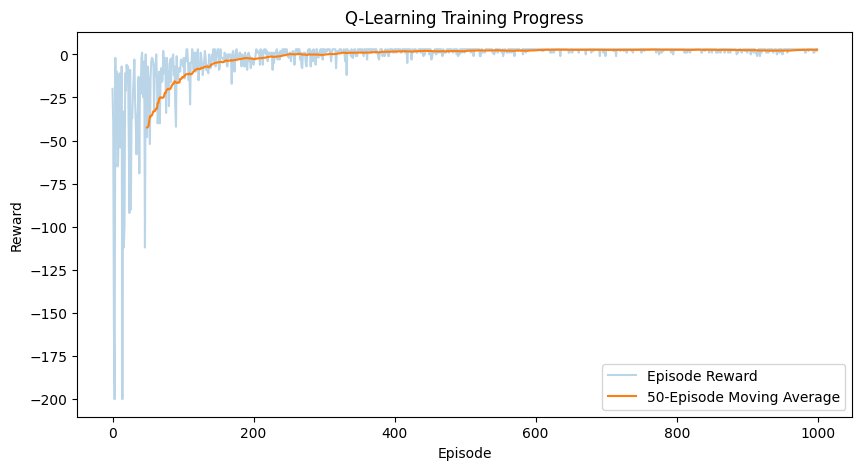

In [9]:
window = 50

rolling_rewards = (
    pd.Series(rewards)
    .rolling(window)
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(rewards, alpha=0.3, label="Episode Reward")
plt.plot(
    rolling_rewards,
    label=f"{window}-Episode Moving Average"
)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Q-Learning Training Progress")
plt.legend()
plt.show()

## 14. Learned Policy

Once Q-Learning has learned the Q-function, the greedy policy is:

$$
\pi(s)
=
\arg\max_a Q(s,a)
$$

We can visualize the preferred action in each state.

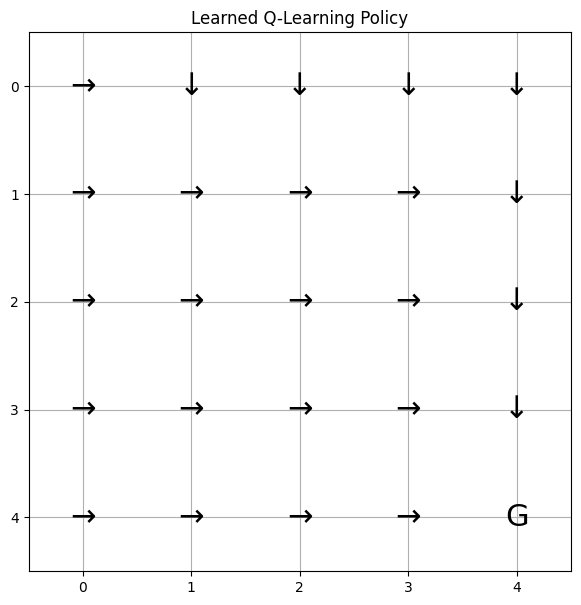

In [10]:
action_symbols = {
    0: "↑",
    1: "↓",
    2: "←",
    3: "→"
}

def plot_policy(Q, env):
    fig, ax = plt.subplots(figsize=(7, 7))

    ax.set_xlim(-0.5, env.size - 0.5)
    ax.set_ylim(env.size - 0.5, -0.5)

    ax.set_xticks(range(env.size))
    ax.set_yticks(range(env.size))
    ax.grid(True)

    for row in range(env.size):
        for col in range(env.size):

            state = (row, col)

            if state == env.goal:
                ax.text(
                    col,
                    row,
                    "G",
                    ha="center",
                    va="center",
                    fontsize=22
                )
                continue

            action = np.argmax(Q[state])

            ax.text(
                col,
                row,
                action_symbols[action],
                ha="center",
                va="center",
                fontsize=22
            )

    ax.set_title("Learned Q-Learning Policy")
    plt.show()


plot_policy(Q, env)

## Value Function

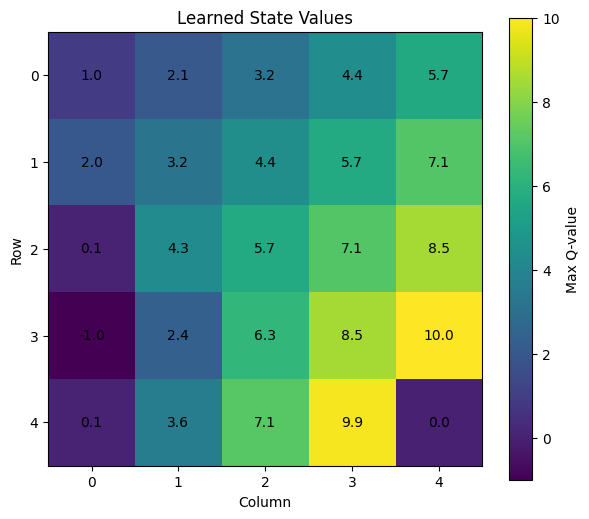

In [11]:
def plot_value_function(Q, env):
    values = np.zeros((env.size, env.size))

    for row in range(env.size):
        for col in range(env.size):
            state = (row, col)
            values[row, col] = np.max(Q[state])

    plt.figure(figsize=(7, 6))

    plt.imshow(values)

    for row in range(env.size):
        for col in range(env.size):
            plt.text(
                col,
                row,
                f"{values[row, col]:.1f}",
                ha="center",
                va="center"
            )

    plt.colorbar(label="Max Q-value")
    plt.title("Learned State Values")
    plt.xlabel("Column")
    plt.ylabel("Row")
    plt.show()


plot_value_function(Q, env)

## 15. SARSA

SARSA is another TD control algorithm.

The name comes from the sequence:

$$
S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1}
$$

Its update rule is:

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma Q(S_{t+1},A_{t+1})
-
Q(S_t,A_t)
\right]
$$

The key difference from Q-Learning is the target.

### Q-Learning

$$
r + \gamma \max_{a'} Q(s',a')
$$

### SARSA

$$
r + \gamma Q(s',a')
$$

Q-Learning is **off-policy**.

SARSA is **on-policy**.

## 16. Q-Learning vs SARSA

| Property | Q-Learning | SARSA |
|---|---|---|
| Type | TD Control | TD Control |
| Policy | Off-policy | On-policy |
| Target | Greedy next action | Actual next action |
| Exploration | Can learn greedy target | Learns current behavior |
| Update | Max Q-value | Q-value of selected action |

Neither algorithm is universally superior.

The appropriate choice depends on the environment and desired behavior.

## 17. Deep Q-Networks

Tabular Q-Learning stores:

$$
Q(s,a)
$$

in a table.

This becomes impractical when the state space is very large.

For example, consider an image-based environment.

A state might contain hundreds of thousands of pixel values.

A Q-table cannot efficiently represent such a space.

Deep Q-Networks address this problem by using a neural network:

$$
Q(s,a;\theta)
$$

where $\theta$ represents the neural network parameters.

The network receives a state and estimates Q-values for possible actions.

## DQN Architecture

A simplified DQN looks like:

$$
\text{State}
\rightarrow
\text{Neural Network}
\rightarrow
Q(s,a_1), Q(s,a_2), \ldots, Q(s,a_n)
$$

For example, with four possible actions:

$$
s
\rightarrow
f_\theta(s)
\rightarrow
[
Q(s,\text{up}),
Q(s,\text{down}),
Q(s,\text{left}),
Q(s,\text{right})
]
$$

The selected action is typically:

$$
a = \arg\max_a Q(s,a;\theta)
$$

## 18. Experience Replay

DQN stores previous interactions in a replay buffer.

Each experience is:

$$
(s,a,r,s',done)
$$

Instead of training only on the most recent experience, the agent samples
random mini-batches from the replay buffer.

This helps:

- reduce correlation between consecutive experiences
- improve data efficiency
- stabilize neural-network training
- reuse previous experiences

## 19. Target Networks

DQN commonly uses two networks:

### Online network

$$
Q(s,a;\theta)
$$

### Target network

$$
Q(s,a;\theta^-)
$$

The target network is updated less frequently.

A typical target is:

$$
y =
r +
\gamma
\max_{a'}
Q(s',a';\theta^-)
$$

The online network is then trained toward this target.

Using a separate target network reduces instability caused by constantly
changing targets.

## 20. Evaluating a Reinforcement Learning Agent

Training reward alone is not enough.

Useful evaluation metrics include:

- Average episode return
- Episode length
- Success rate
- Average reward over multiple episodes
- Performance under different random seeds
- Sample efficiency
- Stability across training runs

A useful evaluation procedure is:

1. Train the agent.
2. Freeze the learned policy.
3. Disable exploration.
4. Run multiple evaluation episodes.
5. Report mean and standard deviation.

## 21. Challenges and Limitations

Reinforcement Learning can be powerful, but it introduces difficult problems.

### 1. Sample inefficiency

Agents may require a large number of interactions.

### 2. Reward design

Poorly designed rewards can produce unintended behavior.

### 3. Exploration

The agent must discover useful actions without knowing the environment.

### 4. Training instability

Deep RL can be considerably less stable than standard supervised learning.

### 5. Reproducibility

Results can vary substantially across random seeds.

### 6. Sparse rewards

If useful rewards are rare, learning can become difficult.

### 7. Sim-to-real gap

Policies trained in simulation may perform poorly in the real world.

## 22. Reinforcement Learning vs Other Learning Paradigms

| Property | Supervised | Unsupervised | Reinforcement |
|---|---|---|---|
| Training signal | Labels | No labels | Rewards |
| Main goal | Predict targets | Discover structure | Maximize return |
| Interaction | Usually none | Usually none | Central |
| Feedback | Immediate label | None | Often delayed |
| Exploration | Not central | Not central | Important |
| Sequential decisions | Optional | Optional | Fundamental |

Reinforcement Learning is particularly suited to **sequential decision
problems** where actions influence future states and rewards.

# 23. Summary

In this notebook we studied the foundations of Reinforcement Learning.

Key concepts:

- Agent and environment
- States and actions
- Rewards
- Markov Decision Processes
- Policies
- Returns
- Discounting
- State-value functions
- Action-value functions
- Bellman equations
- Exploration vs exploitation
- Multi-armed bandits
- Monte Carlo learning
- Temporal-Difference learning
- Q-Learning
- SARSA
- GridWorld
- Policy visualization
- Deep Q-Networks
- Experience replay
- Target networks
- RL evaluation

The central idea is:

$$
\boxed{
\text{Learn a policy that maximizes expected long-term return}
}
$$

Q-Learning provides an important bridge from classical reinforcement
learning to modern deep reinforcement learning.